In [1]:
library(here)
library(pheatmap)
library(corrplot)

here() starts at D:/Studies/FINM_34700_MSA/FINM_34700_MSA

corrplot 0.95 loaded




### Problem 1


In [2]:
path <- here("hw1", "data", "ladyrun25.dat")
ladyrun <- read.table(path)
colnames(ladyrun) <- c("Country","100m","200m","400m","800m","1500m","3000m","Marathon")

print(ladyrun)

   Country  100m  200m  400m 800m 1500m 3000m Marathon
1      ARG 11.17 22.94 52.50 2.05  4.20  9.19   150.32
2      AUS 11.11 22.23 48.63 1.97  4.01  8.63   142.60
3      AUT 11.15 22.70 50.62 1.94  4.05  8.78   154.35
4      BEL 11.04 22.20 51.45 1.97  4.08  8.82   143.05
5      BER 11.28 23.05 53.30 2.07  4.29  9.81   174.18
6      BRA 11.17 22.48 50.62 1.97  4.17  9.04   147.41
7      CAN 10.98 22.50 49.91 1.95  3.94  8.54   146.93
8      CHI 11.65 23.84 53.68 2.00  4.22  9.26   152.23
9      CHN 10.79 22.01 45.14 1.93  3.84  8.10   139.65
10     COL 11.31 22.92 49.64 2.04  4.34  9.37   155.19
11     COK 12.52 25.91 61.65 2.28  4.82 11.10   212.33
12     CRC 11.72 23.92 52.57 2.10  4.52  9.84   164.33
13     CZE 11.09 21.97 47.99 1.89  4.03  8.87   145.19
14     DEN 11.42 23.36 52.92 2.02  4.12  8.71   149.34
15     DOM 11.63 23.91 53.02 2.09  4.54  9.89   166.46
16     FIN 11.13 22.39 50.14 2.01  4.10  8.69   148.00
17     FRA 10.73 21.99 48.25 1.94  4.03  8.35   148.27
18     GER

### a)

In [3]:

print(colMeans(ladyrun[sapply(ladyrun, is.numeric)], na.rm = TRUE))

      100m       200m       400m       800m      1500m      3000m   Marathon 
 11.310370  23.070926  51.820185   2.021296   4.186667   9.067222 153.306852 


### Observations
- Scale of 100m, 200m, 400m is in seconds
- Scale of others is in minutes
- Marathon is less interpretable as the distance for marathon is not mentioned

### b)

In [4]:
# compute covariance matrix
cov_matrix <- cov(ladyrun[sapply(ladyrun, is.numeric)], use = "complete.obs")
print(cov_matrix)

               100m       200m       400m        800m      1500m       3000m
100m     0.15160363 0.33398644  0.9114414 0.025373096 0.08181258  0.23144633
200m     0.33398644 0.82557460  2.2083772 0.060023305 0.19168805  0.53146111
400m     0.91144144 2.20837718  7.4956509 0.191735604 0.55504969  1.56931373
800m     0.02537310 0.06002331  0.1917356 0.007600175 0.02165912  0.06305461
1500m    0.08181258 0.19168805  0.5550497 0.021659119 0.07495849  0.21936604
3000m    0.23144633 0.53146111  1.5693137 0.063054612 0.21936604  0.68175629
Marathon 3.72633326 8.57760297 30.7499534 1.243528686 3.63533836 11.01618166
           Marathon
100m       3.726333
200m       8.577603
400m      30.749953
800m       1.243529
1500m      3.635338
3000m     11.016182
Marathon 276.841762


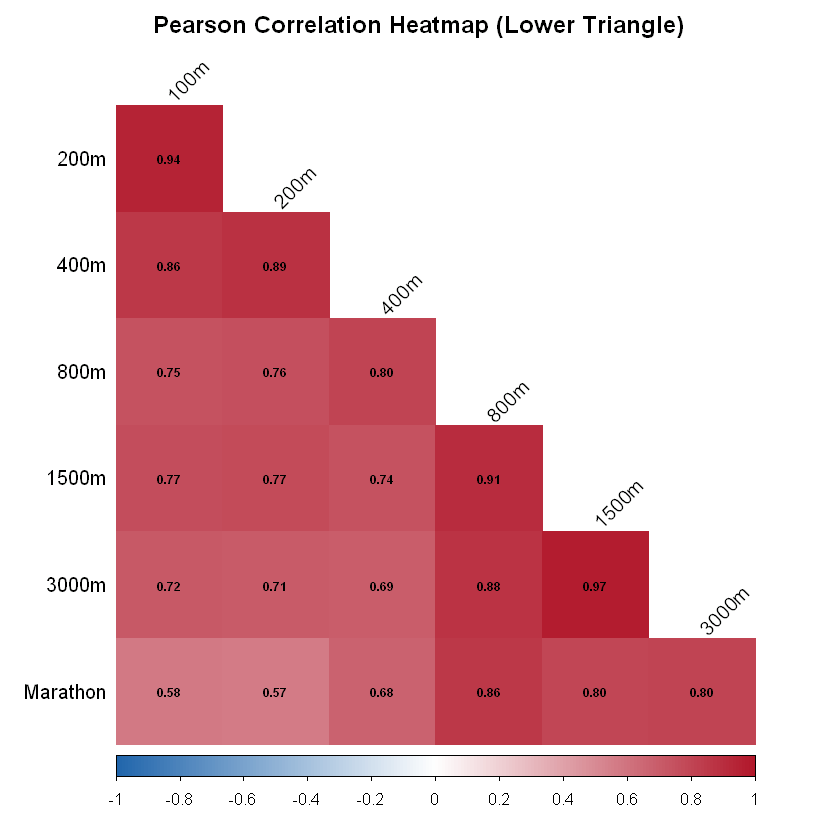

In [5]:
# compute Pearson correlation matrix
pearson_cor_matrix <- cor(ladyrun[sapply(ladyrun, is.numeric)], method = "pearson", use = "complete.obs")
corrplot(
  pearson_cor_matrix,
  method = "color",        # cleaner filled tiles
  type = "lower",          # lower triangle only
  diag = FALSE,              # hide diagonal
  order = "original",      # keep original column order
  tl.col = "black",        # label color
  tl.srt = 45,               # label angle
  col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200),
  addCoef.col = "black",   # print correlation values
  number.cex = 0.6,
  mar = c(0, 0, 2, 0),
  title = "Pearson Correlation Heatmap (Lower Triangle)"
 )

### c)

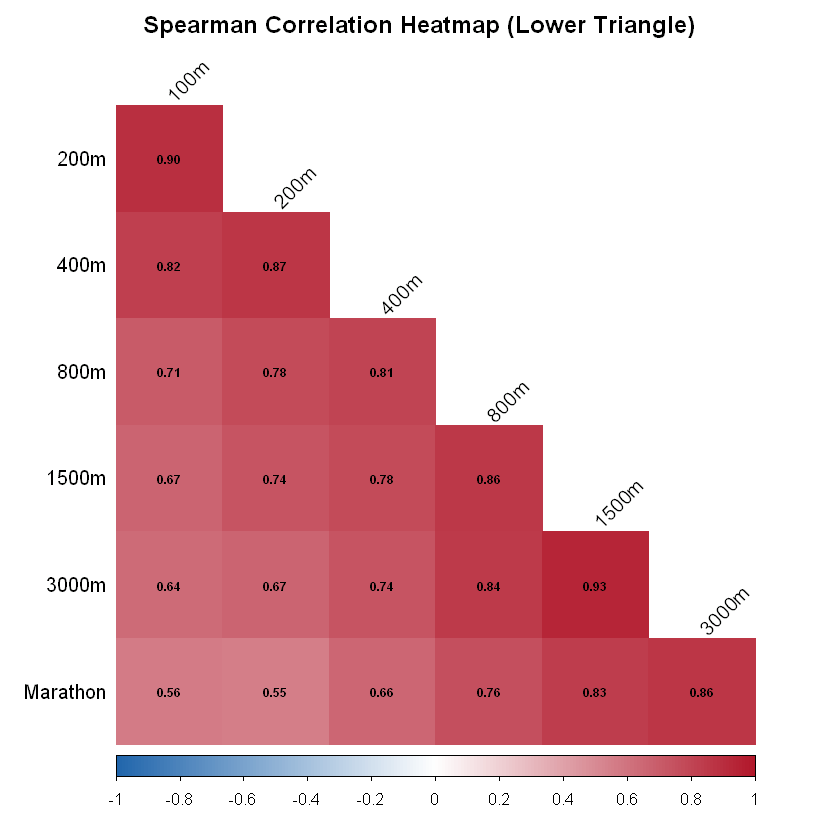

In [6]:
# compute Spearman correlation matrix
spearman_cor_matrix <- cor(ladyrun[sapply(ladyrun, is.numeric)], method = "spearman", use = "complete.obs")
corrplot(
  spearman_cor_matrix,
  method = "color",        # cleaner filled tiles
  type = "lower",          # lower triangle only
  diag = FALSE,              # hide diagonal
  order = "original",      # keep original column order
  tl.col = "black",        # label color
  tl.srt = 45,               # label angle
  col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200),
  addCoef.col = "black",   # print correlation values
  number.cex = 0.6,
  mar = c(0, 0, 2, 0),
  title = "Spearman Correlation Heatmap (Lower Triangle)"
 )

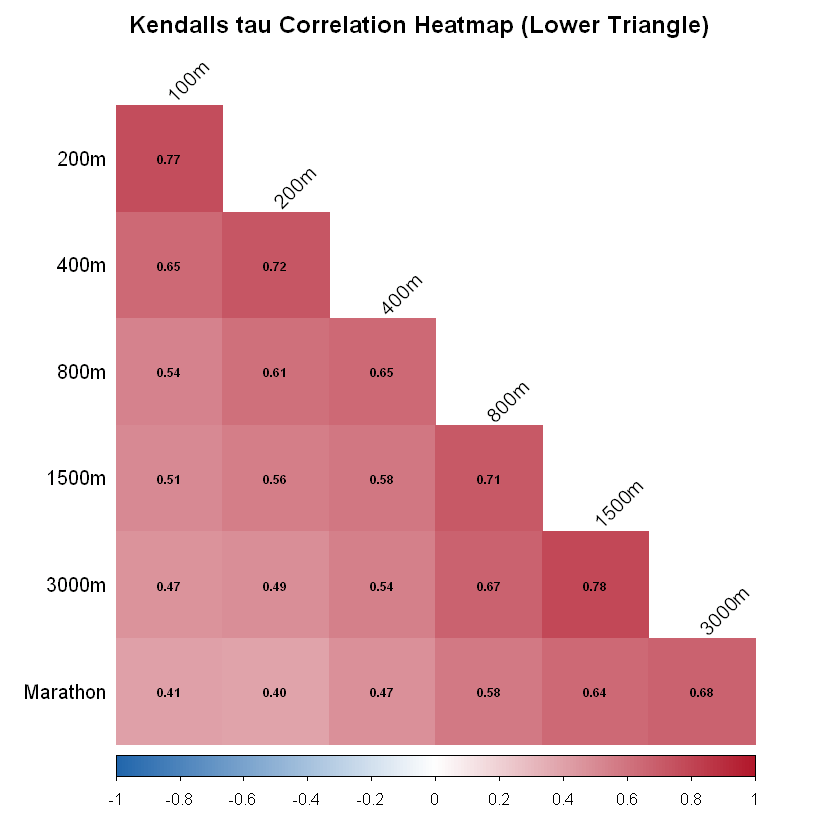

In [7]:
# compute Kendall tau correlation matrix
kendall_cor_matrix <- cor(ladyrun[sapply(ladyrun, is.numeric)], method = "kendall", use = "complete.obs")
corrplot(
  kendall_cor_matrix,
  method = "color",        # cleaner filled tiles
  type = "lower",          # lower triangle only
  diag = FALSE,              # hide diagonal
  order = "original",      # keep original column order
  tl.col = "black",        # label color
  tl.srt = 45,               # label angle
  col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200),
  addCoef.col = "black",   # print correlation values
  number.cex = 0.6,
  mar = c(0, 0, 2, 0),
  title = "Kendalls tau Correlation Heatmap (Lower Triangle)"
 )

 ### d)

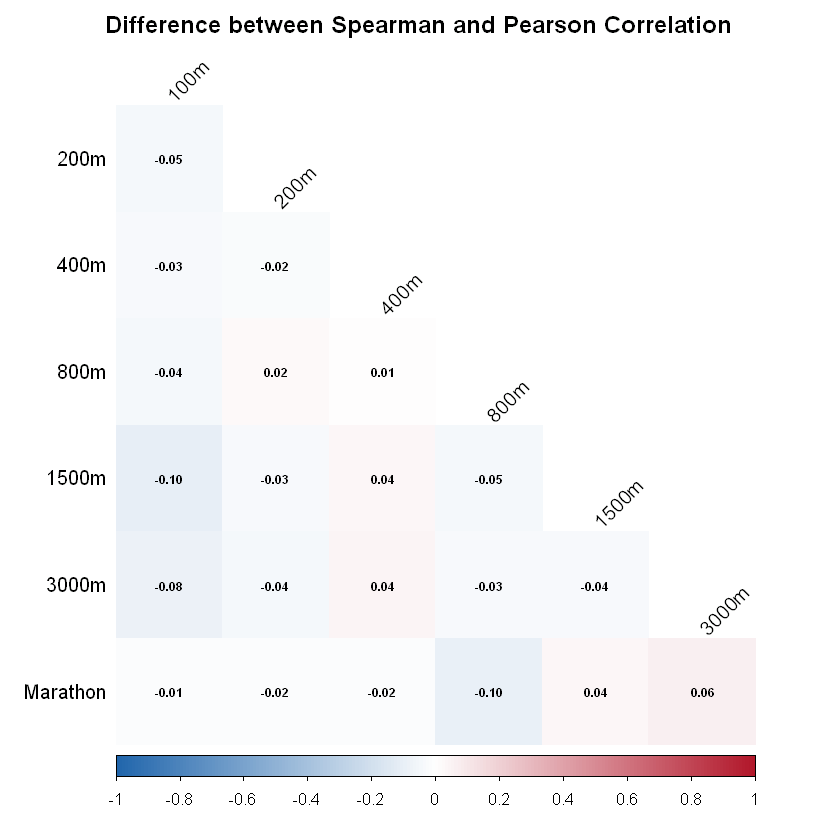

In [8]:
corrplot(
  spearman_cor_matrix - pearson_cor_matrix,
  method = "color",        # cleaner filled tiles
  type = "lower",          # lower triangle only
  diag = FALSE,              # hide diagonal
  order = "original",      # keep original column order
  tl.col = "black",        # label color
  tl.srt = 45,               # label angle
  col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200),
  addCoef.col = "black",   # print correlation values
  number.cex = 0.6,
  mar = c(0, 0, 2, 0),
  title = "Difference between Spearman and Pearson Correlation"
 )

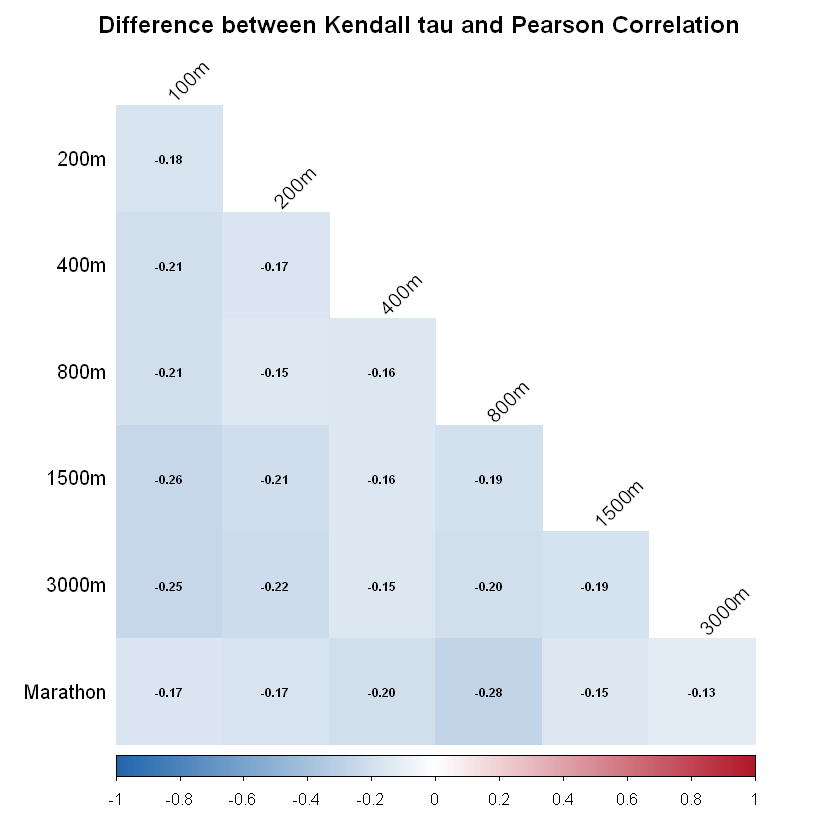

In [9]:
corrplot(
  kendall_cor_matrix - pearson_cor_matrix,
  method = "color",        # cleaner filled tiles
  type = "lower",          # lower triangle only
  diag = FALSE,              # hide diagonal
  order = "original",      # keep original column order
  tl.col = "black",        # label color
  tl.srt = 45,               # label angle
  col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200),
  addCoef.col = "black",   # print correlation values
  number.cex = 0.6,
  mar = c(0, 0, 2, 0),
  title = "Difference between Kendall tau and Pearson Correlation"
 )

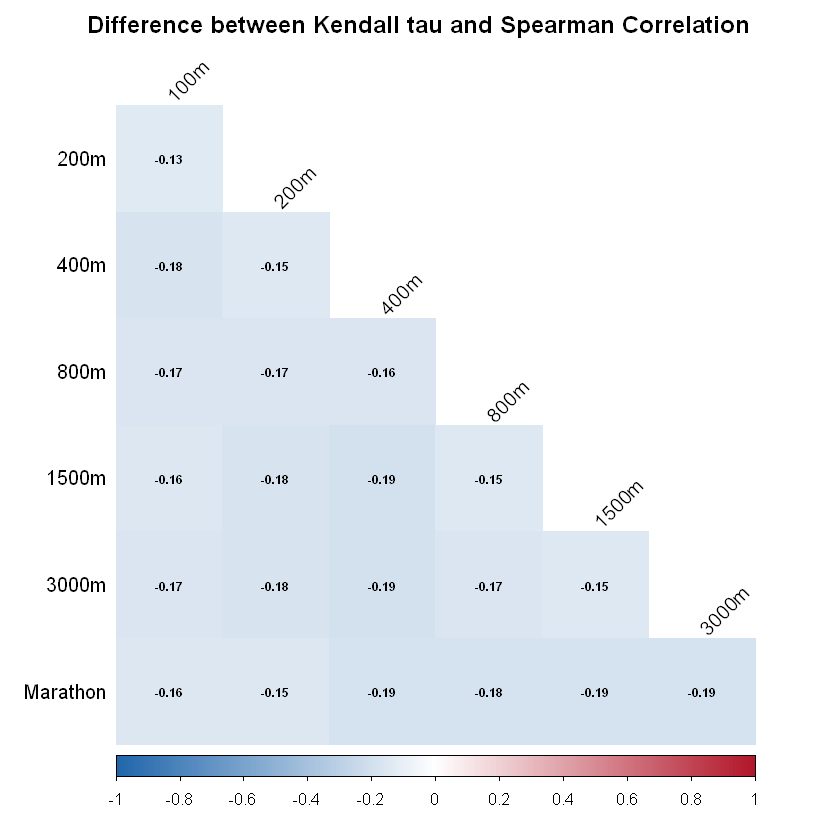

In [10]:
corrplot(
  kendall_cor_matrix - spearman_cor_matrix,
  method = "color",        # cleaner filled tiles
  type = "lower",          # lower triangle only
  diag = FALSE,              # hide diagonal
  order = "original",      # keep original column order
  tl.col = "black",        # label color
  tl.srt = 45,               # label angle
  col = colorRampPalette(c("#2166AC", "white", "#B2182B"))(200),
  addCoef.col = "black",   # print correlation values
  number.cex = 0.6,
  mar = c(0, 0, 2, 0),
  title = "Difference between Kendall tau and Spearman Correlation"
 )


### Observations
- Kendall's tau has the lowest correlation for all pairs
- Spearman and Pearson are closer together with Spearman being slightly lower in many cases but consistently lower

### e)

In [11]:
# compute eigenvalues and eigenvectors of pearson correlation matrix
eigen_pearson <- eigen(pearson_cor_matrix)
print(eigen_pearson$values)
print(eigen_pearson$vectors)

[1] 5.70130407 0.73690632 0.28859891 0.11440672 0.08608808 0.05074016 0.02195575
           [,1]       [,2]        [,3]        [,4]        [,5]       [,6]
[1,] -0.3720342 -0.4575195 -0.14870245  0.52629124 -0.15450205  0.5677425
[2,] -0.3738784 -0.4801563 -0.07423786  0.11131548 -0.09164471 -0.7495258
[3,] -0.3747904 -0.3314811  0.48724807 -0.50849863  0.45647911  0.1996520
[4,] -0.3949123  0.2210770  0.14789147 -0.37710528 -0.76947015  0.1212119
[5,] -0.3956582  0.2305757 -0.42485979 -0.13992068  0.08162078 -0.1431547
[6,] -0.3834289  0.3180749 -0.47659266 -0.07501674  0.37659087  0.1401873
[7,] -0.3490255  0.4970255  0.55267291  0.53351836  0.13707747 -0.1455350
            [,7]
[1,]  0.08348107
[2,] -0.20389904
[3,]  0.07373480
[4,] -0.15592393
[5,]  0.75036695
[6,] -0.59797109
[7,]  0.03296996


### f)

In [12]:
# sum of eigenvalues should equal the number of variables (trace of pearson_cor_matrix) (7 in this case)
print(sum(eigen_pearson$values))

[1] 7


### g)

In [13]:
# variance explained by first principal component
variance_explained <- eigen_pearson$values / sum(eigen_pearson$values)
print(variance_explained[1]*100)

[1] 81.4472


### Observations:
1. The Pearson correlation matrix shows strong positive correlations between the shorter distance events (100m, 200m, 400m) and weaker correlations with the longer distance events (1500m, 3000m, Marathon). This suggests that athletes who perform well in short sprints may not necessarily excel in long-distance events.
2. Correlation of a distance is highest to its closest distances, which is in-line with common expectation.
3. The Spearman and Kendall tau correlation matrices show similar patterns to the Pearson matrix, but with some differences in the strength of correlations. This indicates that while there are monotonic relationships between the events, they may not be perfectly linear.
4. The first principal component explains a significant portion of the variance in the data, indicating that there may be an underlying factor (such as overall athletic ability) that influences performance across all events.

### Problem 3

### a)

### Observations
1) Correlation based PCA is more appropriate as the shorter distances - 100m, 200m, 400m are in seconds and the rest are in minutes.
2) This leads to larger variance for these shorter distances compared to longer distances, whereas intuitively it is common to see larger variances in longer distances.

### b)

In [14]:
# compute pca of the pearson correlation matrix
pca_pearson <- prcomp(ladyrun[sapply(ladyrun, is.numeric)], center = TRUE, scale. = TRUE)
print(summary(pca_pearson))

Importance of components:
                          PC1    PC2     PC3     PC4    PC5     PC6     PC7
Standard deviation     2.3877 0.8584 0.53721 0.33824 0.2934 0.22526 0.14817
Proportion of Variance 0.8145 0.1053 0.04123 0.01634 0.0123 0.00725 0.00314
Cumulative Proportion  0.8145 0.9197 0.96097 0.97732 0.9896 0.99686 1.00000


In [15]:
# show the factor loadings of PC1 and PC2 to see which variables contribute most to these components
print(pca_pearson$rotation[, 1:2])

               PC1        PC2
100m     0.3720342  0.4575195
200m     0.3738784  0.4801563
400m     0.3747904  0.3314811
800m     0.3949123 -0.2210770
1500m    0.3956582 -0.2305757
3000m    0.3834289 -0.3180749
Marathon 0.3490255 -0.4970255


### c)

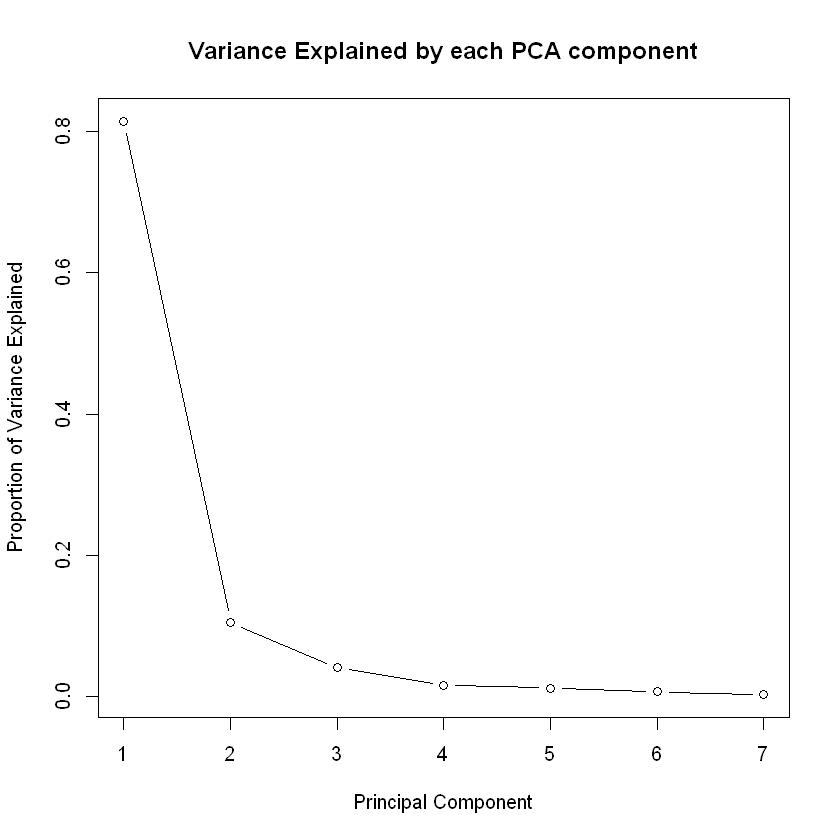

In [16]:
# plot variance explained by each principal component
variance_explained <- pca_pearson$sdev^2 / sum(pca_pearson$sdev^2)
plot(variance_explained, type = "b", xlab = "Principal Component", ylab = "Proportion of Variance Explained", main = "Variance Explained by each PCA component")

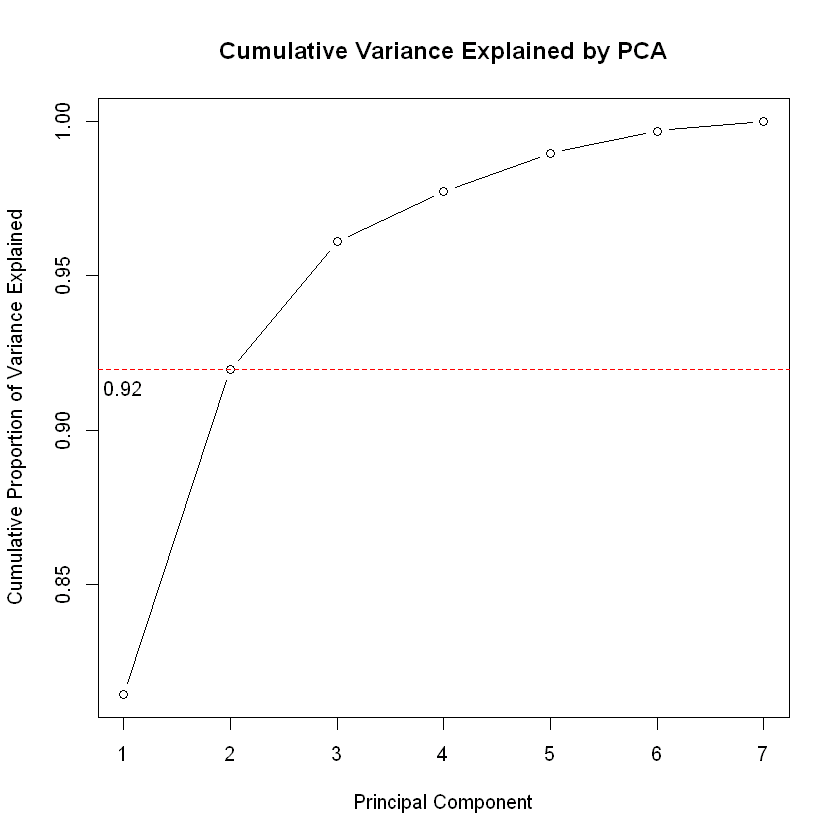

In [17]:
# plot cumulative variance explained by each principal component
plot(cumsum(pca_pearson$sdev^2 / sum(pca_pearson$sdev^2)), type = "b", xlab = "Principal Component", ylab = "Cumulative Proportion of Variance Explained", main = "Cumulative Variance Explained by PCA")
# add a horizontal line at the variance explained by the first two components
abline(h = sum(variance_explained[1:2]), col = "red", lty = 2)
# mark the value on y-axis
text(x = 1, y = sum(variance_explained[1:2]), labels = round(sum(variance_explained[1:2]), 2), pos = 1)

### Observations

1) The number of components to retain depend on the proportion of total variance that we want our analysis to retain.
2) For 90% variance explained, we will choose first two components.
3) For 95% variance explained, we will choose first three components.

### d)

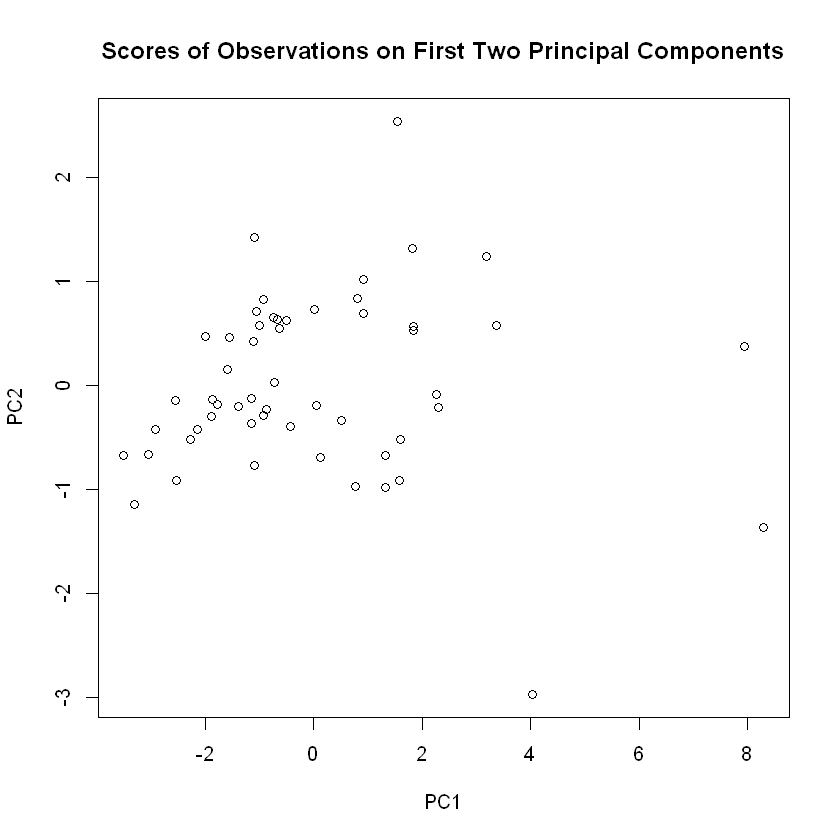

In [18]:
# plot scores of the observations on the first two principal components
X_std <- scale(ladyrun[sapply(ladyrun, is.numeric)])

scores = X_std %*% pca_pearson$rotation[, 1:2]

plot(scores, xlab = "PC1", ylab = "PC2", main = "Scores of Observations on First Two Principal Components")

### Observations
1) Variance of the scores is higher on PC1 compared to PC2.
2) There is some visible clustering of the scores near origin, with few outliers.

### e)

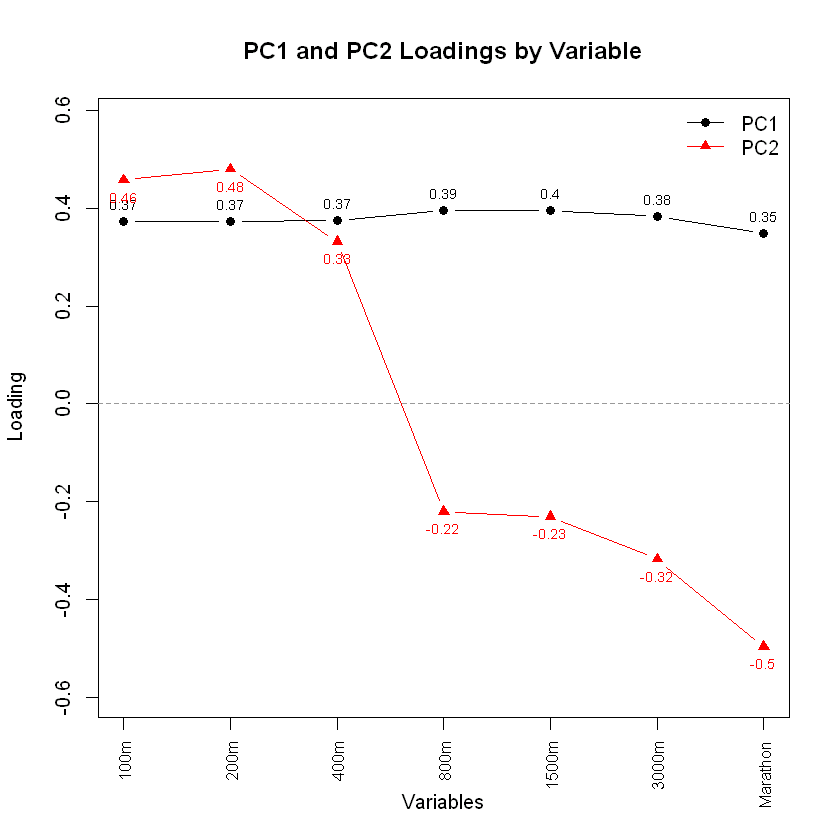

In [19]:
pc1 <- pca_pearson$rotation[, 1]
pc2 <- pca_pearson$rotation[, 2]
vars <- rownames(pca_pearson$rotation)
x <- seq_along(vars)

y_all <- c(pc1, pc2)
pad <- 0.1 * diff(range(y_all))

plot(
  x, pc1,
  type = "b", pch = 19, col = "black",
  xaxt = "n",
  ylim = c(min(y_all) - pad, max(y_all) + pad),  # increased y-limits
  xlab = "Variables",
  ylab = "Loading",
  main = "PC1 and PC2 Loadings by Variable"
)

lines(x, pc2, type = "b", pch = 17, col = "red")
axis(1, at = x, labels = vars, las = 2, cex.axis = 0.8)
abline(h = 0, col = "gray60", lty = 2)

# numeric labels near points
text(x, pc1, labels = round(pc1, 2), pos = 3, cex = 0.7, col = "black")
text(x, pc2, labels = round(pc2, 2), pos = 1, cex = 0.7, col = "red")

legend("topright", legend = c("PC1", "PC2"), col = c("black", "red"),
       lty = 1, pch = c(19, 17), bty = "n")
# ...existing code...

### Observations:
1) The first PC represents level with almost equal factor loading to all distances. It may be measuring the overall athletic level.
2) The second PC represents slope with positive weight to shorter distances and negative to longer distances. It may be measuring the gradient between shorter and distance times.

### f)

In [20]:
# compute pca of the covariance matrix
pca_cov <- prcomp(ladyrun[sapply(ladyrun, is.numeric)], center = TRUE, scale. = FALSE)
print(summary(pca_cov))

Importance of components:
                           PC1     PC2     PC3     PC4     PC5     PC6    PC7
Standard deviation     16.7670 2.12734 0.54149 0.33417 0.11724 0.05608 0.0273
Proportion of Variance  0.9827 0.01582 0.00102 0.00039 0.00005 0.00001 0.0000
Cumulative Proportion   0.9827 0.99852 0.99955 0.99994 0.99999 1.00000 1.0000


In [21]:
# show the factor loadings of PC1 and PC2 to see which variables contribute most to these components
print(pca_cov$rotation[, 1:2])

                 PC1         PC2
100m     0.013596494  0.12014073
200m     0.031347197  0.30270344
400m     0.112057518  0.93290950
800m     0.004483292  0.01248659
1500m    0.013111954  0.03742880
3000m    0.039683998  0.08670969
Marathon 0.992224147 -0.12058732


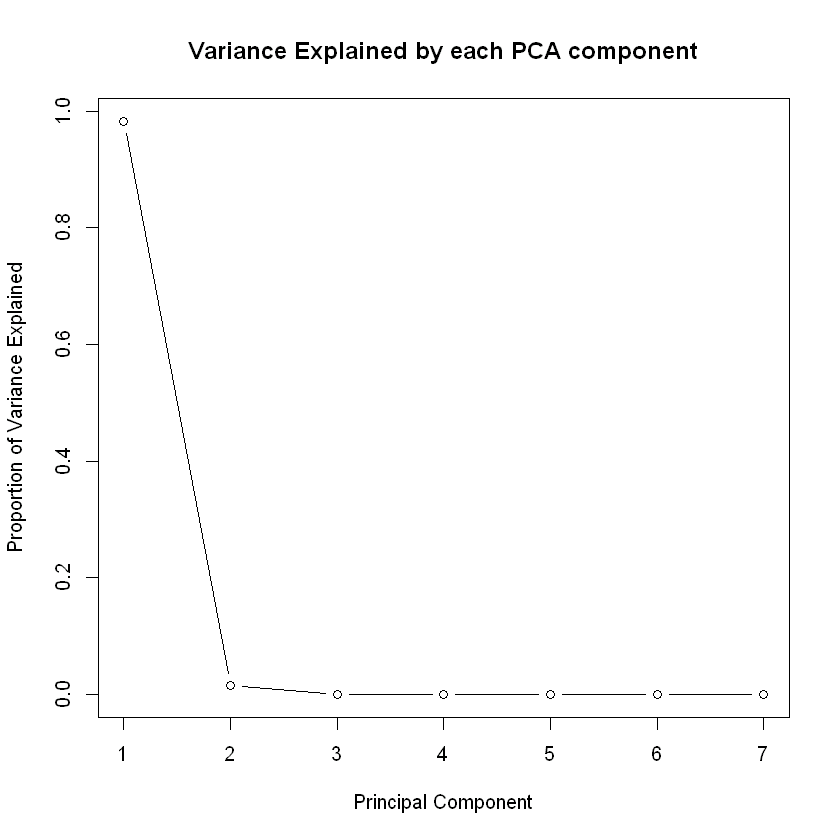

In [22]:
# plot variance explained by each principal component
variance_explained <- pca_cov$sdev^2 / sum(pca_cov$sdev^2)
plot(variance_explained, type = "b", xlab = "Principal Component", ylab = "Proportion of Variance Explained", main = "Variance Explained by each PCA component")

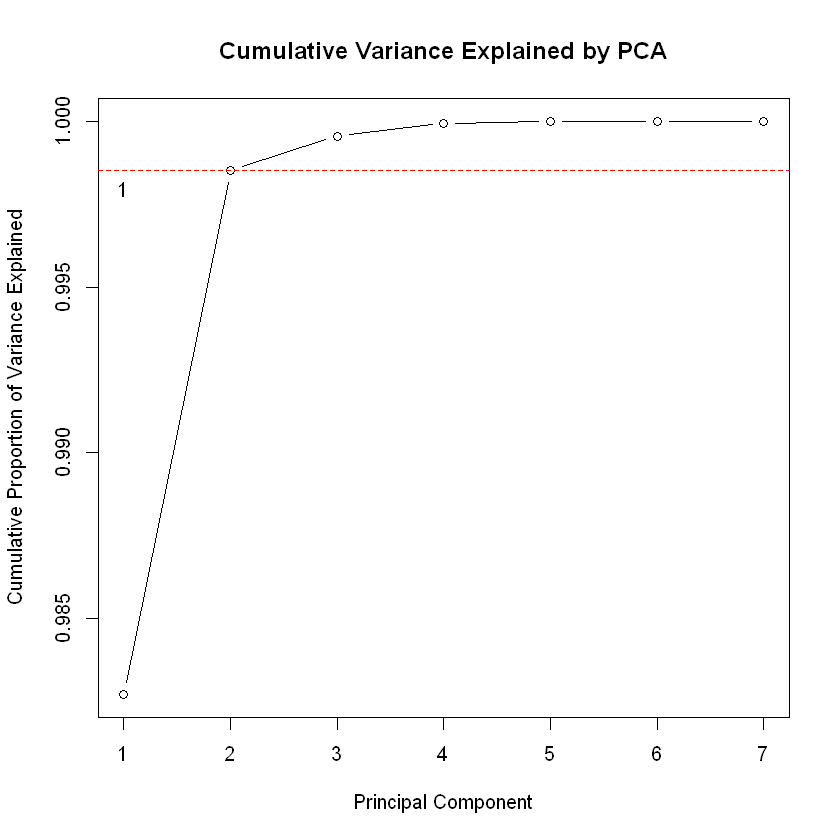

In [23]:
# plot cumulative variance explained by each principal component
plot(cumsum(variance_explained), type = "b", xlab = "Principal Component", ylab = "Cumulative Proportion of Variance Explained", main = "Cumulative Variance Explained by PCA")
# add a horizontal line at the variance explained by the first two components
abline(h = sum(variance_explained[1:2]), col = "red", lty = 2)
# mark the value on y-axis
text(x = 1, y = sum(variance_explained[1:2]), labels = round(sum(variance_explained[1:2]), 2), pos = 1)

### Observations

1) Almost all of the variance is explained by the first PC

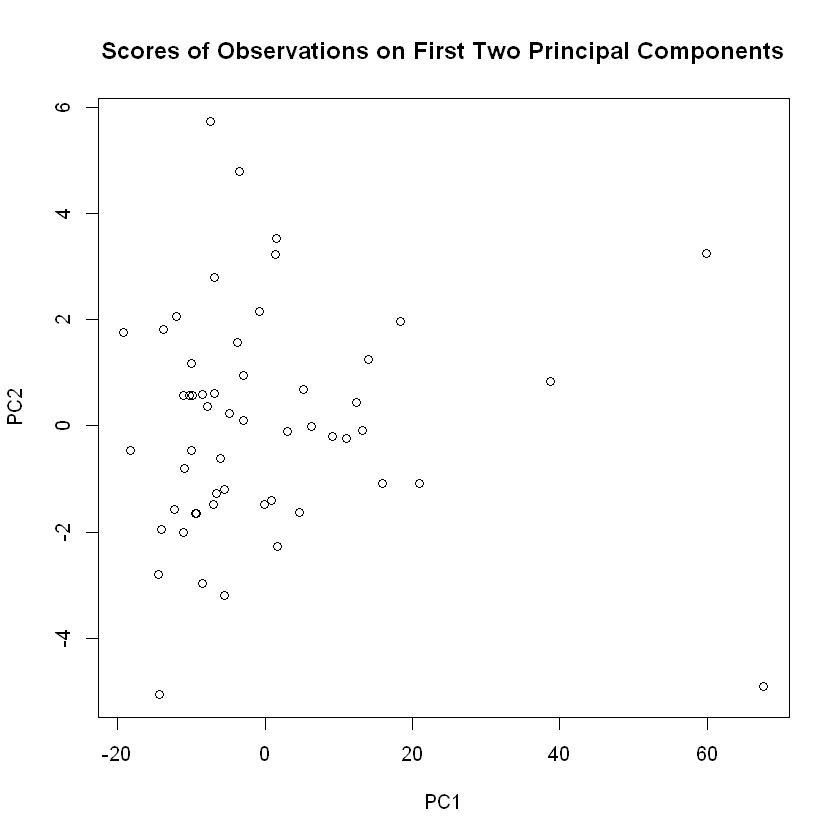

In [24]:
# plot scores of the observations on the first two principal components
X_demean <- scale(ladyrun[sapply(ladyrun, is.numeric)], scale=FALSE)

scores = X_demean %*% pca_cov$rotation[, 1:2]

plot(scores, xlab = "PC1", ylab = "PC2", main = "Scores of Observations on First Two Principal Components")

### Observations:
1) The scale of PC1 is much larger than PC2, which indicates that PC1 explains much more variance than PC2. This is consistent with the variance explained plot where the first component explains a large portion of the variance.

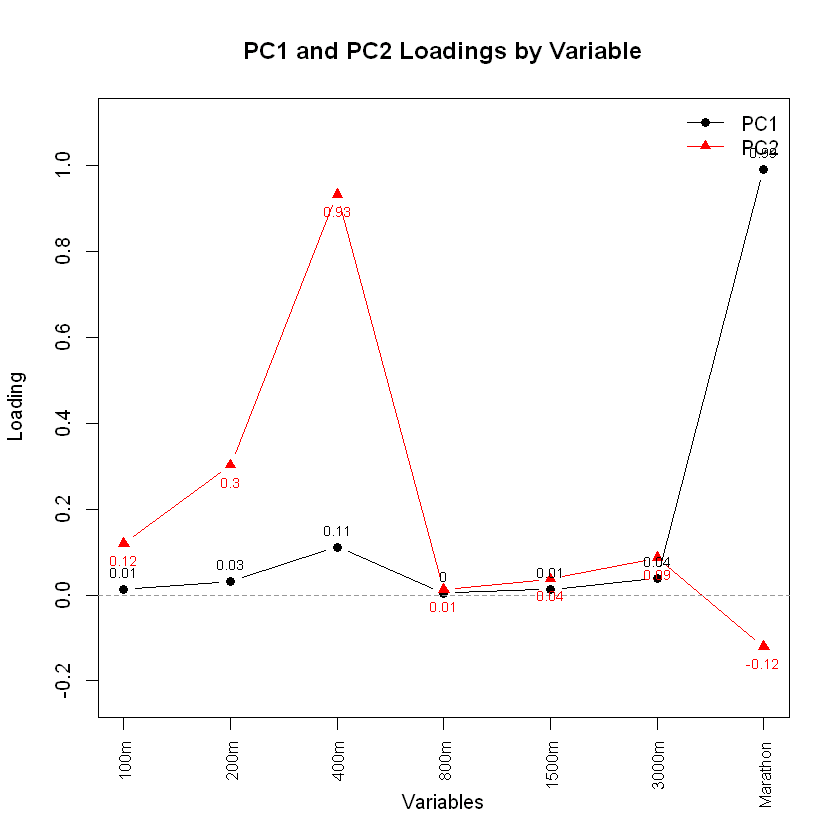

In [25]:
pc1 <- pca_cov$rotation[, 1]
pc2 <- pca_cov$rotation[, 2]
vars <- rownames(pca_cov$rotation)
x <- seq_along(vars)

y_all <- c(pc1, pc2)
pad <- 0.1 * diff(range(y_all))

plot(
  x, pc1,
  type = "b", pch = 19, col = "black",
  xaxt = "n",
  ylim = c(min(y_all) - pad, max(y_all) + pad),  # increased y-limits
  xlab = "Variables",
  ylab = "Loading",
  main = "PC1 and PC2 Loadings by Variable"
)

lines(x, pc2, type = "b", pch = 17, col = "red")
axis(1, at = x, labels = vars, las = 2, cex.axis = 0.8)
abline(h = 0, col = "gray60", lty = 2)

# numeric labels near points
text(x, pc1, labels = round(pc1, 2), pos = 3, cex = 0.7, col = "black")
text(x, pc2, labels = round(pc2, 2), pos = 1, cex = 0.7, col = "red")

legend("topright", legend = c("PC1", "PC2"), col = c("black", "red"),
       lty = 1, pch = c(19, 17), bty = "n")

### Observations:
1) PC1 has maximum factor loadings on 400m and second largest on 200m and negative loadings on Marathon.
2) PC2 has maximum factor loadings on Marathon.

### g)

### Observations:
1) PCA conclusions are highly sensitive to the choice of covariance vs correlation matrix (standardization) when the scale of all the variables is not the same.
2) PCA on Correlation matrix is the correct approach in our case.

### Problem 4)

In [26]:
path <- here("hw1", "data", "treasury_yield_panel.csv")
treasury_yield_panel <- read.csv(path)

print(head(treasury_yield_panel))

        date  X1Y  X2Y  X3Y  X5Y  X7Y X10Y X20Y X30Y
1 2014-01-02 0.13 0.39 0.76 1.72 2.41 3.00 3.68 3.92
2 2014-01-03 0.13 0.41 0.80 1.73 2.42 3.01 3.69 3.93
3 2014-01-06 0.12 0.40 0.78 1.70 2.38 2.98 3.66 3.90
4 2014-01-07 0.13 0.40 0.80 1.69 2.37 2.96 3.64 3.88
5 2014-01-08 0.13 0.43 0.87 1.77 2.44 3.01 3.67 3.90
6 2014-01-09 0.13 0.44 0.86 1.75 2.41 2.97 3.62 3.88


### a)

In [27]:
# Calculate daily changes in yields in bps for each maturity
yield_changes_bps <- treasury_yield_panel
num_cols <- sapply(yield_changes_bps, is.numeric)

k <- 1
yield_changes_bps[num_cols] <- lapply(
  yield_changes_bps[num_cols],
  function(x) c(rep(NA, k), diff(x, lag = k))
)

yield_changes_bps[num_cols] <- 1e4 * yield_changes_bps[num_cols]

yield_changes_bps <- yield_changes_bps[complete.cases(yield_changes_bps), ]

print(head(yield_changes_bps))

        date  X1Y  X2Y  X3Y   X5Y   X7Y X10Y X20Y X30Y
2 2014-01-03    0  200  400   100   100  100  100  100
3 2014-01-06 -100 -100 -200  -300  -400 -300 -300 -300
4 2014-01-07  100    0  200  -100  -100 -200 -200 -200
5 2014-01-08    0  300  700   800   700  500  300  200
6 2014-01-09    0  100 -100  -200  -300 -400 -500 -200
7 2014-01-10 -100 -500 -900 -1100 -1200 -900 -800 -800


### b)

In [28]:
# apply pca to the centered yield changes in bps
pca_yield_changes <- prcomp(yield_changes_bps[sapply(yield_changes_bps, is.numeric)], center = TRUE, scale. = FALSE)
print(summary(pca_yield_changes))

Importance of components:
                             PC1      PC2       PC3       PC4      PC5      PC6
Standard deviation     1319.1917 476.5249 213.60352 132.53831 94.26186 68.36535
Proportion of Variance    0.8482   0.1107   0.02224   0.00856  0.00433  0.00228
Cumulative Proportion     0.8482   0.9589   0.98112   0.98968  0.99401  0.99629
                            PC7      PC8
Standard deviation     66.95945 55.93084
Proportion of Variance  0.00219  0.00152
Cumulative Proportion   0.99848  1.00000


In [29]:
print(pca_yield_changes$rotation[, 1:3])

           PC1         PC2          PC3
X1Y  0.2056368 -0.43464427  0.789147203
X2Y  0.3321860 -0.46305493  0.002025498
X3Y  0.3723304 -0.33858862 -0.250518251
X5Y  0.4033192 -0.12038526 -0.329321447
X7Y  0.4098169  0.06141526 -0.235730411
X10Y 0.3850044  0.22025556 -0.052376753
X20Y 0.3480298  0.42840217  0.215198015
X30Y 0.3297977  0.48136977  0.318446610


In [30]:
# variance explained by first three principal components
variance_explained <- pca_yield_changes$sdev^2 / sum(pca_yield_changes$sdev^2)
print(variance_explained[1:3]*100)

[1] 84.82045 11.06766  2.22383


### c)

In [31]:
xc = scale(yield_changes_bps[sapply(yield_changes_bps, is.numeric)], center = TRUE, scale = FALSE)

v1 = pca_yield_changes$rotation[, 1]
v2 = pca_yield_changes$rotation[, 2]

z1 = xc %*% v1
z2 = xc %*% v2

xc_2 = z1 %*% t(v1) + z2 %*% t(v2)

### c)(i)

In [32]:
r = xc - xc_2

In [33]:
print(head(r %*% v1))
print(tail(r %*% v1))

           [,1]
2  1.598721e-14
3  1.207923e-13
4  3.108624e-14
5 -2.273737e-13
6  6.394885e-14
7  2.629008e-13
              [,1]
3040 -4.014566e-13
3041 -1.598721e-14
3042 -9.570122e-14
3043 -4.973799e-14
3044 -3.552714e-15
3045 -2.486900e-14


In [34]:
print(sum((r %*% v1) > 1e-10))

[1] 0


In [35]:
print(head(r %*% v2))
print(tail(r %*% v2))

          [,1]
2 1.438849e-13
3 8.881784e-14
4 2.629008e-13
5 1.563194e-13
6 3.979039e-13
7 2.486900e-13
              [,1]
3040  4.654055e-13
3041  2.238210e-13
3042  2.648992e-13
3043  9.947598e-14
3044 -6.181722e-13
3045  4.121148e-13


In [36]:
print(sum((r %*% v2) > 1e-10))

[1] 0


### c)(ii)

In [39]:
# find norm of each residual row
residual_norms <- apply(r, 1, function(row) sqrt(sum(row^2)))
print(head(residual_norms))
print(tail(residual_norms))


       2        3        4        5        6        7 
271.2101 122.2386 201.3597 556.6132 271.2502 468.9174 


    3040     3041     3042     3043     3044     3045 
134.7054 243.2861 144.5018 224.9579 252.9636 129.2823 


In [40]:
# find index of the max of the residual norms
max_residual_norm <- max(residual_norms)
max_residual_index <- which(residual_norms == max_residual_norm)
print(max_residual_index)

2299 
2298 


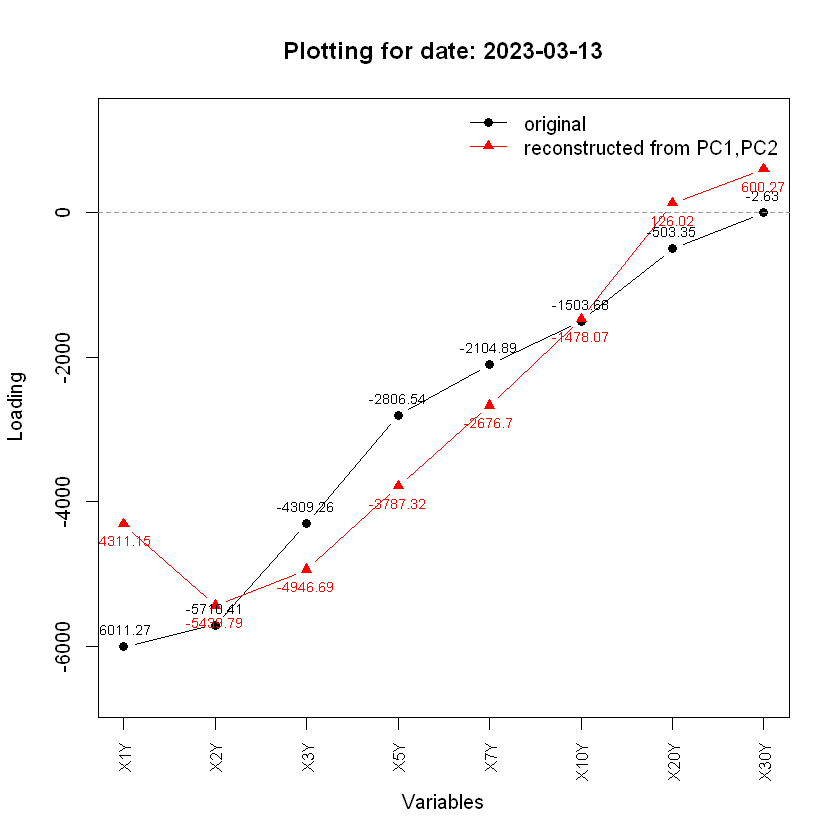

In [41]:
# plot xc, xc_2, and r for the observation with the largest residual norm for numeric columns
index_to_plot <- max_residual_index[1]  # in case there are multiple, just take the first one
date <- yield_changes_bps[index_to_plot, 'date']

vars <- colnames(xc)
x <- seq_along(vars)

y_all <- c(xc[index_to_plot, ], xc_2[index_to_plot, ])
pad <- 0.1 * diff(range(y_all))

plot(
  x, xc[index_to_plot, ],
  type = "b", pch = 19, col = "black",
  xaxt = "n",
  ylim = c(min(y_all) - pad, max(y_all) + pad),  # increased y-limits
  xlab = "Variables",
  ylab = "Loading",
  main = paste("Plotting for date:", date)
)

lines(x, xc_2[index_to_plot, ], type = "b", pch = 17, col = "red")
axis(1, at = x, labels = vars, las = 2, cex.axis = 0.8)
abline(h = 0, col = "gray60", lty = 2)

# numeric labels near points
text(x, xc[index_to_plot, ], labels = round(xc[index_to_plot, ], 2), pos = 3, cex = 0.7, col = "black")
text(x, xc_2[index_to_plot, ], labels = round(xc_2[index_to_plot, ], 2), pos = 1, cex = 0.7, col = "red")

legend("topright", legend = c("original", "reconstructed from PC1,PC2"), col = c("black", "red"), lty = 1, pch = c(19, 17), bty = "n")

### Observations:
1) The level moves are largely captured by the two component reconstruction.
2) The slope is also largely captured by the two component reconstruction.
3) The curvature is not captured by the first two components as we can visibly note that the lower and higher terms are reduced less in comparison to the original and medium terms are reduced more in comparison to the original.

### Problem 5)

### a)

In [42]:
# fit a two factor factor-analysis model to ladyrun using factanal
data <- ladyrun[sapply(ladyrun, is.numeric)]
factanal_result <- factanal(data, factors = 2)
print(factanal_result)


Call:
factanal(x = data, factors = 2)

Uniquenesses:
    100m     200m     400m     800m    1500m    3000m Marathon 
   0.097    0.009    0.194    0.155    0.018    0.037    0.324 

Loadings:
         Factor1 Factor2
100m     0.411   0.856  
200m     0.375   0.922  
400m     0.425   0.790  
800m     0.762   0.514  
1500m    0.865   0.483  
3000m    0.894   0.405  
Marathon 0.761   0.311  

               Factor1 Factor2
SS loadings      3.198   2.966
Proportion Var   0.457   0.424
Cumulative Var   0.457   0.881

Test of the hypothesis that 2 factors are sufficient.
The chi square statistic is 33.71 on 8 degrees of freedom.
The p-value is 4.58e-05 


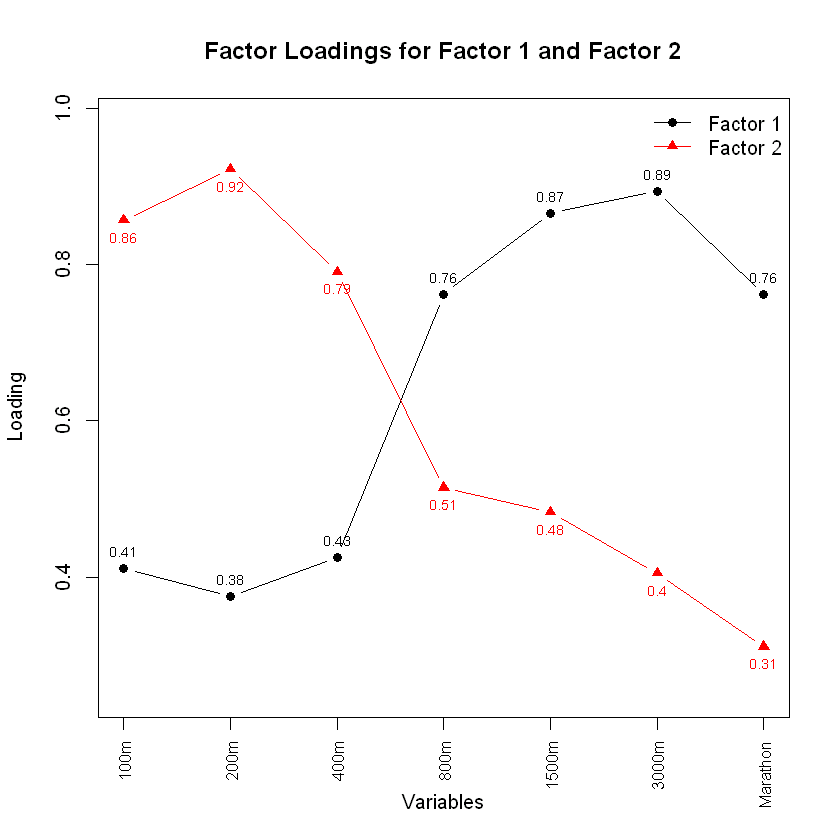

In [43]:
# plot the factor loadings of the two factors
loadings <- factanal_result$loadings[, 1:2]

vars <- colnames(data)
x <- seq_along(vars)

y_all <- c(loadings[, 1], loadings[, 2])
pad <- 0.1 * diff(range(y_all))

plot(
  x, loadings[, 1],
  type = "b", pch = 19, col = "black",
  xaxt = "n",
  ylim = c(min(y_all) - pad, max(y_all) + pad),  # increased y-limits
  xlab = "Variables",
  ylab = "Loading",
  main = "Factor Loadings for Factor 1 and Factor 2"
)

lines(x, loadings[, 2], type = "b", pch = 17, col = "red")
axis(1, at = x, labels = vars, las = 2, cex.axis = 0.8)
abline(h = 0, col = "gray60", lty = 2)

# numeric labels near points
text(x, loadings[, 1], labels = round(loadings[, 1], 2), pos = 3, cex = 0.7, col = "black")
text(x, loadings[, 2], labels = round(loadings[, 2], 2), pos = 1, cex = 0.7, col = "red")

legend("topright", legend = c("Factor 1", "Factor 2"), col = c("black", "red"), lty = 1, pch = c(19, 17), bty = "n")

### b)

### Observations:
1) Factor 1 loads the longer distances more strongly.
2) Factor 2 loads the shorter distances more strongly.
3) Marathon seems to have the largest uniqueness, followed by 400m and 800m (in the order).

### c)

### Observations:
1) Similarity: Two factor Factor-analysis (trying to capture common variance) explained about 90% of the variance similar to two factor PCA (trying to capture total variance).
2) Difference: The first PC component captured the maximum variance (90%) in the data, while the first factor captured less than 50% of the variance in the data.

____